# Hyperparameter Experimentation

## Objective

To experiment with different hyperparameters of a CNN
and compare their effect on model performance.

## Hyperparameters

- Learning Rate
- Batch Size
- Number of Epochs

## Dataset

MNIST Handwritten Digit Dataset

## Framework

PyTorch

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Libraries imported successfully!")

PyTorch version: 2.11.0
Libraries imported successfully!


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:13<00:00, 713kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 82.1kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 363kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.69MB/s]

Training samples: 60000
Testing samples: 10000


In [6]:
def create_model():

    class CNN(nn.Module):

        def __init__(self):
            super().__init__()

            self.conv1 = nn.Conv2d(
                1, 16, kernel_size=3, padding=1
            )

            self.conv2 = nn.Conv2d(
                16, 32, kernel_size=3, padding=1
            )

            self.pool = nn.MaxPool2d(2, 2)

            self.fc1 = nn.Linear(
                32 * 7 * 7,
                128
            )

            self.fc2 = nn.Linear(
                128,
                10
            )

        def forward(self, x):

            x = torch.relu(self.conv1(x))
            x = self.pool(x)

            x = torch.relu(self.conv2(x))
            x = self.pool(x)

            x = x.view(x.size(0), -1)

            x = torch.relu(self.fc1(x))

            x = self.fc2(x)

            return x

    return CNN().to(device)


print("CNN model function created successfully!")

CNN model function created successfully!


In [7]:
def train_model(model, train_loader, learning_rate, epochs):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {average_loss:.4f}"
        )

    return model

In [8]:
def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import pandas as pd
import matplotlib.pyplot as plt

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [12]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [15]:
def create_model():

    class CNN(nn.Module):

        def __init__(self):
            super().__init__()

            self.conv1 = nn.Conv2d(
                1, 16, kernel_size=3, padding=1
            )

            self.conv2 = nn.Conv2d(
                16, 32, kernel_size=3, padding=1
            )

            self.pool = nn.MaxPool2d(2, 2)

            self.fc1 = nn.Linear(
                32 * 7 * 7,
                128
            )

            self.fc2 = nn.Linear(
                128,
                10
            )

        def forward(self, x):

            x = torch.relu(self.conv1(x))
            x = self.pool(x)

            x = torch.relu(self.conv2(x))
            x = self.pool(x)

            x = x.view(x.size(0), -1)

            x = torch.relu(self.fc1(x))

            x = self.fc2(x)

            return x

    return CNN().to(device)

print("CNN model created successfully!")

CNN model created successfully!


In [16]:
def train_model(model, train_loader, learning_rate, epochs):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader)

        print(
            f"Epoch {epoch + 1}/{epochs} - Loss: {average_loss:.4f}"
        )

    return model


def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

print("Training and evaluation functions created successfully!")

Training and evaluation functions created successfully!


In [21]:
experiments = [
    {
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "learning_rate": 0.01,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 64,
        "epochs": 3
    },
    {
        "learning_rate": 0.001,
        "batch_size": 128,
        "epochs": 3
    }
]

print("Number of experiments:", len(experiments))

for i, experiment in enumerate(experiments, 1):
    print("Experiment", i, ":", experiment)

Number of experiments: 4
Experiment 1 : {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 3}
Experiment 2 : {'learning_rate': 0.01, 'batch_size': 64, 'epochs': 3}
Experiment 3 : {'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 3}
Experiment 4 : {'learning_rate': 0.001, 'batch_size': 128, 'epochs': 3}


In [22]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [23]:
results = []

for i, experiment in enumerate(experiments, 1):

    print("\n" + "=" * 50)
    print("Experiment", i)
    print("=" * 50)

    learning_rate = experiment["learning_rate"]
    batch_size = experiment["batch_size"]
    epochs = experiment["epochs"]

    print("Learning Rate:", learning_rate)
    print("Batch Size:", batch_size)
    print("Epochs:", epochs)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = create_model()

    model = train_model(
        model,
        train_loader,
        learning_rate,
        epochs
    )

    accuracy = evaluate_model(
        model,
        test_loader
    )

    results.append({
        "Experiment": i,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Test Accuracy": accuracy
    })

    print("Test Accuracy:", f"{accuracy:.2f}%")

print("\nAll experiments completed successfully!")


Experiment 1
Learning Rate: 0.001
Batch Size: 64
Epochs: 3
Epoch 1/3 - Loss: 0.2361
Epoch 2/3 - Loss: 0.0595
Epoch 3/3 - Loss: 0.0424
Test Accuracy: 98.55%

Experiment 2
Learning Rate: 0.01
Batch Size: 64
Epochs: 3
Epoch 1/3 - Loss: 0.2024
Epoch 2/3 - Loss: 0.0927
Epoch 3/3 - Loss: 0.0812
Test Accuracy: 97.42%

Experiment 3
Learning Rate: 0.0001
Batch Size: 64
Epochs: 3
Epoch 1/3 - Loss: 0.7493
Epoch 2/3 - Loss: 0.2141
Epoch 3/3 - Loss: 0.1429
Test Accuracy: 96.69%

Experiment 4
Learning Rate: 0.001
Batch Size: 128
Epochs: 3
Epoch 1/3 - Loss: 0.2901
Epoch 2/3 - Loss: 0.0728
Epoch 3/3 - Loss: 0.0504
Test Accuracy: 98.57%

All experiments completed successfully!


In [24]:
results_df = pd.DataFrame(results)
results_df

,Experiment,Learning Rate,Batch Size,Epochs,Test Accuracy
0,1,0.0010,64,3,98.55
1,2,0.0100,64,3,97.42
2,3,0.0001,64,3,96.69
3,4,0.0010,128,3,98.57


In [25]:
best_experiment = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

print("Experiment with highest test accuracy:")
print(best_experiment)

Experiment with highest test accuracy:
Experiment         4.000
Learning Rate      0.001
Batch Size       128.000
Epochs             3.000
Test Accuracy     98.570
Name: 3, dtype: float64


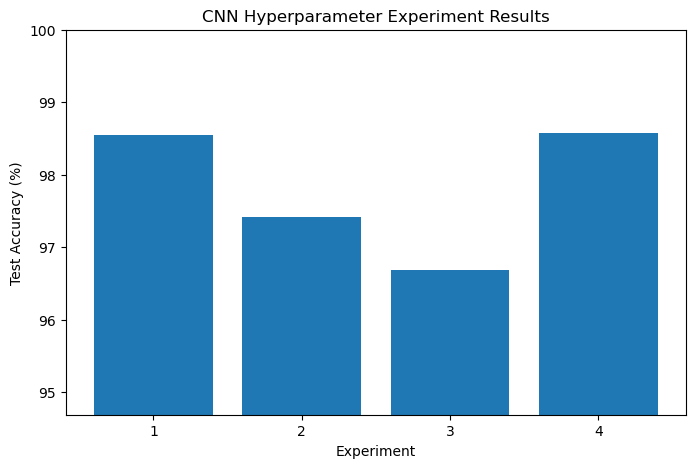

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Experiment"].astype(str),
    results_df["Test Accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN Hyperparameter Experiment Results")

plt.ylim(
    min(results_df["Test Accuracy"]) - 2,
    100
)

plt.show()

In [27]:
results_df.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print("Experiment results saved successfully!")

Experiment results saved successfully!


In [28]:
import os

print("Current Jupyter folder:")
print(os.getcwd())

Current Jupyter folder:
C:\Users\LENOVO\Desktop\Week2_AIML\Task_3


In [29]:
print(os.listdir())

['.ipynb_checkpoints', 'data', 'hyperparameter_results.csv', 'Task3_Hyperparameter_Experimentation.ipynb']


# Conclusion

Hyperparameter experimentation was performed using a CNN model
on the MNIST handwritten digit dataset.

Different learning rates and batch sizes were tested while
keeping the number of epochs controlled.

The test accuracy of each experiment was recorded and compared
using a results table and bar chart.

The experiment demonstrates that changing hyperparameters can
affect the performance of a deep learning model.

The experimental results were saved in `hyperparameter_results.csv`.